In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score



In [16]:
# =======================
# STEP 1: Load & Clean Data
# =======================
df = pd.read_csv("/Users/robinkumar/Downloads/electricity_consumption_dataset.csv")

/var/folders/3n/k6yccvbd1xq9v6hstx5r8_c00000gn/T/ipykernel_76946/1463092530.py:4: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/robinkumar/Downloads/electricity_consumption_dataset.csv")


In [17]:


# Clean column names
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("#", "number")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

# Rename known columns
df.rename(columns={"tds_": "tds_number", "#_days": "number_days"}, inplace=True)

# Convert dates
date_columns = ["revenue_month", "service_start_date", "service_end_date"]
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Convert 'estimated' to boolean
if "estimated" in df.columns:
    df["estimated"] = df["estimated"].map({"Y": True, "N": False})

# Convert numeric columns
numeric_columns = [
    "current_charges", "consumption_kwh", "kwh_charges",
    "consumption_kw", "kw_charges", "other_charges",
    "number_days", "tds_number"
]
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean string columns
string_columns = df.select_dtypes(include="object").columns
for col in string_columns:
    df[col] = df[col].astype(str).str.strip()



In [18]:

# =======================
# STEP 3: Preprocessing
# =======================
df = df.dropna()  # For simplicity

# Encode string columns
label_encoders = {}
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Convert datetime features to numerical features
for col in date_columns:
    if col in df.columns:
        df[col + "_year"] = df[col].dt.year
        df[col + "_month"] = df[col].dt.month
        df[col + "_day"] = df[col].dt.day
        # Add other relevant features like dayofweek, weekofyear, etc. as needed
        df.drop(columns=[col], inplace=True) 

Dataset Shape: (519149, 33)

Missing Values:
 development_name            0
borough                     0
account_name                0
location                    0
meter_amr                   0
meter_scope                 0
tds_number                  0
edp                         0
rc_code                     0
funding_source              0
amp_number                  0
vendor_name                 0
umis_bill_id                0
number_days                 0
meter_number                0
estimated                   0
current_charges             0
rate_class                  0
bill_analyzed               0
consumption_kwh             0
kwh_charges                 0
consumption_kw              0
kw_charges                  0
other_charges               0
revenue_month_year          0
revenue_month_month         0
revenue_month_day           0
service_start_date_year     0
service_start_date_month    0
service_start_date_day      0
service_end_date_year       0
service_end_date_month  

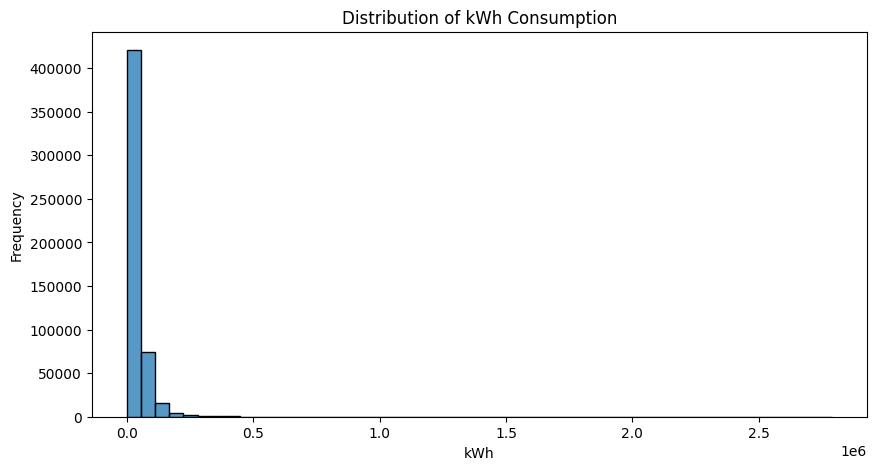

In [19]:
# =======================
# STEP 2: Basic EDA
# =======================
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

# Distribution Plot
if "consumption_kwh" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df["consumption_kwh"].dropna(), bins=50)
    plt.title("Distribution of kWh Consumption")
    plt.xlabel("kWh")
    plt.ylabel("Frequency")
    plt.show()

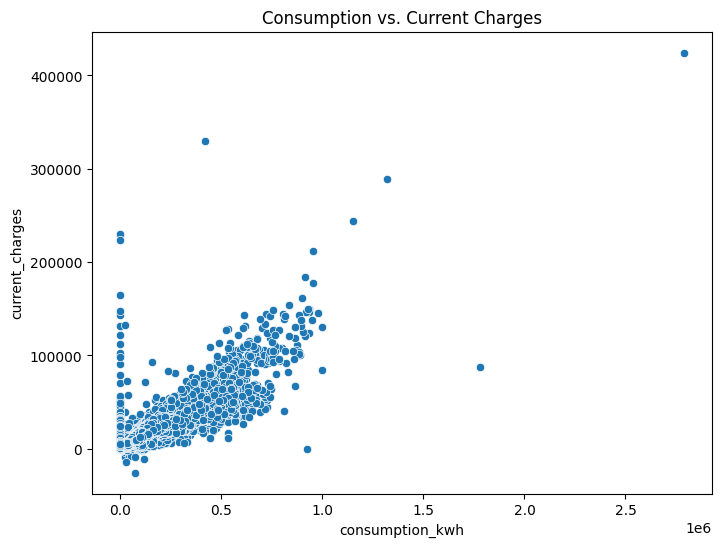

In [21]:
# Scatter Plots for Relationships between Features
# Example: Consumption vs. Current Charges
plt.figure(figsize=(8, 6))
sns.scatterplot(x='consumption_kwh', y='current_charges', data=df)
plt.title('Consumption vs. Current Charges')
plt.show()

In [20]:
# =======================
# STEP 4: Train & Evaluate Models
# =======================
if "current_charges" in df.columns:
    X = df.drop(columns=["current_charges"])
    y = df["current_charges"] > df["current_charges"].median()  # binary classification

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=1000)
    }

    def evaluate_model(name, model):
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        print(f"\nModel: {name}")
        print("Accuracy :", accuracy_score(y_test, preds))
        print("Precision:", precision_score(y_test, preds))
        print("F1 Score :", f1_score(y_test, preds))

    for name, model in models.items():
        evaluate_model(name, model)


Model: Random Forest
Accuracy : 0.9981315612058173
Precision: 0.9983389025167558
F1 Score : 0.9981268345434884

Model: Logistic Regression
Accuracy : 0.9996340171434075
Precision: 0.999671757641289
F1 Score : 0.9996331550595641


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


###Here's a clear summary of how to **hand off your trained model** so others can run it reliably:

---

### ✅ 1. Save the Model

Use `joblib` (or `pickle`) to serialize the model:

```python
import joblib

# Save the model to disk
joblib.dump(best_model, "random_forest_model.pkl")
joblib.dump(logistic_model, "logistic_regression_model.pkl")
```

---

### ✅ 2. Document Inputs & Outputs

Provide a README or in-code doc with:
- **Input features** (names, types, encoding)
- **Expected format** (Pandas DataFrame, JSON, etc.)
- **Output format** (e.g., 0 = Low, 1 = High consumption)

---

### ✅ 3. Provide a Reusable Inference Script

Example inference code:

```python
import joblib
import pandas as pd

# Load model
model = joblib.load("random_forest_model.pkl")

# Example input (must match feature structure)
input_data = pd.DataFrame([{
    "borough": 1,
    "rate_class": 2,
    "number_days": 30,
    "current_charges": 1450.5,
    "consumption_kw": 198.0,
    "kw_charges": 790.0,
    "estimated": 0
}])

# Predict
prediction = model.predict(input_data)
print("Predicted Class:", prediction[0])
```

---

### ✅ 4. Optional: Deploy as an API

Using **FastAPI**:

```python
# fastapi_app.py
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()
model = joblib.load("random_forest_model.pkl")

@app.post("/predict")
def predict(data: dict):
    input_df = pd.DataFrame([data])
    result = model.predict(input_df)[0]
    return {"prediction": int(result)}
```

Run it:
```bash
uvicorn fastapi_app:app --reload
```

---

### ✅ 5. Share with Others

- Include everything in a folder:
  - `.pkl` model file
  - `inference.py` (script)
  - `fastapi_app.py` (optional API)
  - `requirements.txt`:
    ```txt
    pandas
    scikit-learn
    joblib
    fastapi
    uvicorn
    ```

---

Would you like me to generate and upload this entire handoff folder for you as a zip?